# 프로젝트 모델의 BF16 백엔드 실제 추론 비교

실측 JSON과 재현 가능한 모델·벤치마크 source를 내장한 노트북입니다. 기본 실행은 GPU 없이 결과를 재분석합니다. NumPy와 Matplotlib이 필요하며 Colab 기본 환경에서 사용할 수 있습니다.

PyTorch는 컴파일 버전이며 CUDA 결과에는 직접 작성한 CUDA C++와 cuBLAS가 포함됩니다. 하드웨어별 최적화의 제한과 미수행 후보를 결과와 함께 기록했습니다.

In [1]:
# 기본 실행은 저장된 실측 결과만 재분석합니다. GPU를 사용하려면 True로 바꾸세요.
RUN_BENCHMARK = False
import base64, gzip, hashlib, json, sys
from pathlib import Path
PAYLOAD = '...'
compressed = base64.b64decode(PAYLOAD)
assert hashlib.sha256(compressed).hexdigest() == '230bc0503a19c2e5adbeb9dcb0772d9a5e388a31e61add9b31141b4fd5b5d3a4'
archive = json.loads(gzip.decompress(compressed))
base = Path('/content') if Path('/content').exists() else Path.cwd()
REPRO_ROOT = base / 'tensor2silicon_benchmark_reproduction'
for relative, source in archive['sources'].items():
    target = REPRO_ROOT / relative
    assert target.resolve().is_relative_to(REPRO_ROOT.resolve())
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source)
RESULTS_DIR = REPRO_ROOT / 'llm_bench' / 'results' / 'embedded-final'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for name, data in archive['runs'].items():
    (RESULTS_DIR / (name + '.json')).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['sidecars'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_bytes(base64.b64decode(archive['sidecars_raw'][name]))
for name, data in archive['candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['torch_candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['native_candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
sys.path.insert(0, str(REPRO_ROOT))
runs = list(archive['runs'].items())
print('복원 위치:', REPRO_ROOT)
source_mismatches = {}
for name, data in runs:
    env = data['environment']
    print(name, env['gpu'], 'PyTorch', env['torch'], 'Triton', env['triton'], 'CUDA', env['cuda'])
    configured = data.get('arguments', {}).get('tuning_config')
    if configured and data.get('tuning_config_sha256'):
        actual_hash = hashlib.sha256((RESULTS_DIR / Path(configured).name).read_bytes()).hexdigest()
        assert actual_hash == data['tuning_config_sha256'], 'Tuning config SHA-256 mismatch'
    source_mismatches[name] = [path for path, digest in env.get('source_sha256', {}).items()
                               if path != 'llm_bench/report.py' and
                               (path not in archive['sources'] or
                                hashlib.sha256(archive['sources'][path].encode()).hexdigest() != digest)]
    print('측정 때의 compute source와 다른 파일:', source_mismatches[name])


복원 위치: /tmp/llm-cuda-notebook-s6ija3j5/tensor2silicon_benchmark_reproduction
final-run1 NVIDIA RTX PRO 6000 Blackwell Server Edition PyTorch 2.11.0+cu130 Triton 3.6.0 CUDA 13.0
측정 때의 compute source와 다른 파일: []
final-run2 NVIDIA RTX PRO 6000 Blackwell Server Edition PyTorch 2.11.0+cu130 Triton 3.6.0 CUDA 13.0
측정 때의 compute source와 다른 파일: []


## 선택: GPU 재측정

기본값은 저장 결과 분석입니다. 재측정하려면 위 cell의 `RUN_BENCHMARK=True`로 바꿉니다. 기록된 GPU/소프트웨어 환경과 현재 런타임을 비교하세요. 컴파일·autotune·정확성 검증은 steady-state 측정 전에 수행됩니다.

In [2]:
# GPU 재측정은 최대 수십 분 이상 걸릴 수 있습니다. 모델/패키지 다운로드는 하지 않습니다.
if RUN_BENCHMARK:
    import os, subprocess, torch, triton, importlib.util
    if any(b in ("cuda", "hybrid-cuda") for _, data in runs for b in data.get("backends", [])):
        if importlib.util.find_spec("ninja") is None:
            subprocess.run([sys.executable, "-m", "pip", "install", "ninja"], check=True)
    assert torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    assert not any(source_mismatches.values()), '기록된 source와 다른 파일을 먼저 확인하세요.'
    print('재측정 GPU:', torch.cuda.get_device_name(), 'torch:', torch.__version__, 'triton:', triton.__version__)
    refreshed = []
    for name, saved in runs:
        args = saved['arguments']
        output = RESULTS_DIR / (name + '-rerun.json')
        command = [sys.executable, '-m', 'llm_bench', '--backend', 'all', '--preset', args.get('preset', 'colab'),
                   '--workload', 'all', '--seed', str(args.get('seed', 123)), '--profile', '--out', str(output)]
        if args.get('reverse'):
            command.append('--reverse')
        if args.get('hybrid_attention'):
            command += ['--hybrid-attention', args['hybrid_attention']]
        if args.get('hybrid_matmul'):
            command += ['--hybrid-matmul', args['hybrid_matmul']]
        if args.get('torch_attention'):
            command += ['--torch-attention', args['torch_attention']]
        if args.get('tuning_config'):
            tuning_config = RESULTS_DIR / Path(args['tuning_config']).name
            assert tuning_config.exists()
            command += ['--tuning-config', str(tuning_config)]
        subprocess.run(command, cwd=REPRO_ROOT, check=True)
        refreshed.append((name + '-rerun', json.loads(output.read_text())))
    runs = refreshed
else:
    print('저장된 실제 측정 결과를 사용합니다. RUN_BENCHMARK=False')


저장된 실제 측정 결과를 사용합니다. RUN_BENCHMARK=False


In [3]:
from llm_bench.report import records_from_runs, render_report, plot_records
from IPython.display import Markdown, display, Image
records = records_from_runs(runs)
display(Markdown(render_report(runs, records, archive['inventory'], archive['sidecars'],
                              list(archive['candidates'].items()), str(RESULTS_DIR),
                              list(archive['torch_candidates'].items()), list(archive['native_candidates'].items()))))


# PyTorch·Triton·CUDA BF16 전체 모델 비교

무작위 가중치의 동일한 8층 decoder, BF16 가중치·activation·KV·logits를 사용했다. FP32 reference 검증은 성능 측정에서 제외했다.
Prefill B1/T2048, 고정 decode B8/S2048, 연속 생성 B1/prompt2048/128토큰이다. 모든 prompt 위치의 logits를 계산한다.

## 구현 경계

| Backend | 계산 방식 |
| --- | --- |
| PyTorch compile | Inductor compile; PyTorch GEMM, SDPA/FlexAttention |
| PyTorch + Triton compile | 직접 작성 Triton 작은 연산; final-run1: compiled PyTorch GEMM, prefill/고정 decode SDPA + 연속 생성 FlexAttention; final-run2: compiled PyTorch GEMM, prefill/고정 decode SDPA + 연속 생성 FlexAttention |
| PyTorch + CUDA compile | 작은 연산만 직접 작성 CUDA C++; GEMM·attention은 PyTorch |
| Native Triton | 직접 작성 Triton으로 모델 계산·KV 쓰기·토큰 선택 |
| Native CUDA (cuBLAS) | 직접 작성 CUDA C++ + cuBLAS; PyTorch는 저장소·준비·Graph 관리 |

혼합 경로의 작은 연산은 embedding, affine LayerNorm, residual+LayerNorm, RoPE+KV 쓰기, SwiGLU, argmax 및 cache/token 보조 연산이다. 세 compile 경로의 attention 정책은 실행 인자에 기록한다. Inductor가 생성하는 Triton은 허용되며 사용자 작성 Triton과 구분한다.
Native CUDA prefill attention은 cuBLAS QK → CUDA causal softmax → cuBLAS PV이며 FP32 score 행렬과 BF16 확률 행렬을 저장한다. Fused FlashAttention 구현이 아니므로 native Triton과의 차이는 언어 자체의 차이로 해석할 수 없다. Decode는 FP32 online softmax와 32-way split-KV CUDA 커널이다. cuBLAS GEMM은 BF16 입출력, FP32 누산을 사용한다.

## 측정 결과

배속은 같은 실행의 PyTorch compile 대비 값이다. 각 실행의 중앙값을 따로 보고하며 표본을 합치지 않는다.

| 실행 | Backend | Prefill ms | Decode ms | 128-token ms | TTFT ms | TPOT ms |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | 6.856 | 1.545 | 158.336 | 7.161 | 1.190 |
| final-run1 | PyTorch + Triton compile | 6.865 | 1.544 | 158.651 | 7.086 | 1.193 |
| final-run1 | Native Triton | 7.173 | 1.588 | 126.596 | 7.500 | 0.938 |
| final-run1 | PyTorch + CUDA compile | 7.297 | 1.631 | 168.338 | 7.568 | 1.266 |
| final-run1 | Native CUDA (cuBLAS) | 10.315 | 1.751 | 195.141 | 10.596 | 1.453 |
| final-run2 | PyTorch compile | 6.870 | 1.543 | 158.388 | 7.180 | 1.191 |
| final-run2 | PyTorch + Triton compile | 6.899 | 1.544 | 157.681 | 7.091 | 1.186 |
| final-run2 | Native Triton | 7.156 | 1.591 | 126.427 | 7.389 | 0.937 |
| final-run2 | PyTorch + CUDA compile | 7.299 | 1.631 | 168.628 | 7.568 | 1.268 |
| final-run2 | Native CUDA (cuBLAS) | 10.312 | 1.749 | 195.138 | 10.599 | 1.453 |

<details><summary>전체 시간 지표와 배속</summary>

| 실행 | Backend | Workload | 측정 | 중앙값 ms | p95 ms | 배속 |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | CUDA Graph GPU 시간 | 6.856 | 6.858 | 1.000 |
| final-run1 | PyTorch compile | prefill | CUDA Graph 동기화 wall 시간 | 6.865 | 6.872 | 1.000 |
| final-run1 | PyTorch compile | prefill | Graph 없는 GPU 시간 | 7.017 | 7.019 | 1.000 |
| final-run1 | PyTorch compile | prefill | Graph 없는 동기화 wall 시간 | 7.067 | 7.082 | 1.000 |
| final-run1 | PyTorch compile | decode | CUDA Graph GPU 시간 | 1.545 | 1.546 | 1.000 |
| final-run1 | PyTorch compile | decode | CUDA Graph 동기화 wall 시간 | 1.579 | 1.582 | 1.000 |
| final-run1 | PyTorch compile | decode | Graph 없는 GPU 시간 | 1.708 | 1.709 | 1.000 |
| final-run1 | PyTorch compile | decode | Graph 없는 동기화 wall 시간 | 1.781 | 1.795 | 1.000 |
| final-run1 | PyTorch compile | generate | 128-token 생성 GPU 시간 | 158.336 | 158.364 | 1.000 |
| final-run1 | PyTorch compile | generate | 128-token 생성 wall 시간 | 158.351 | 158.378 | 1.000 |
| final-run1 | PyTorch compile | generate | GPU TTFT | 7.161 | 7.166 | 1.000 |
| final-run1 | PyTorch compile | generate | GPU decode ms/token | 1.190 | 1.191 | 1.000 |
| final-run1 | PyTorch + Triton compile | prefill | CUDA Graph GPU 시간 | 6.865 | 6.869 | 0.999 |
| final-run1 | PyTorch + Triton compile | prefill | CUDA Graph 동기화 wall 시간 | 6.901 | 6.907 | 0.995 |
| final-run1 | PyTorch + Triton compile | prefill | Graph 없는 GPU 시간 | 7.004 | 7.005 | 1.002 |
| final-run1 | PyTorch + Triton compile | prefill | Graph 없는 동기화 wall 시간 | 7.065 | 7.073 | 1.000 |
| final-run1 | PyTorch + Triton compile | decode | CUDA Graph GPU 시간 | 1.544 | 1.544 | 1.001 |
| final-run1 | PyTorch + Triton compile | decode | CUDA Graph 동기화 wall 시간 | 1.576 | 1.578 | 1.002 |
| final-run1 | PyTorch + Triton compile | decode | Graph 없는 GPU 시간 | 1.690 | 1.690 | 1.011 |
| final-run1 | PyTorch + Triton compile | decode | Graph 없는 동기화 wall 시간 | 1.763 | 1.772 | 1.010 |
| final-run1 | PyTorch + Triton compile | generate | 128-token 생성 GPU 시간 | 158.651 | 158.672 | 0.998 |
| final-run1 | PyTorch + Triton compile | generate | 128-token 생성 wall 시간 | 158.664 | 158.685 | 0.998 |
| final-run1 | PyTorch + Triton compile | generate | GPU TTFT | 7.086 | 7.093 | 1.011 |
| final-run1 | PyTorch + Triton compile | generate | GPU decode ms/token | 1.193 | 1.194 | 0.997 |
| final-run1 | Native Triton | prefill | CUDA Graph GPU 시간 | 7.173 | 7.177 | 0.956 |
| final-run1 | Native Triton | prefill | CUDA Graph 동기화 wall 시간 | 7.201 | 7.265 | 0.953 |
| final-run1 | Native Triton | prefill | Graph 없는 GPU 시간 | 7.266 | 7.267 | 0.966 |
| final-run1 | Native Triton | prefill | Graph 없는 동기화 wall 시간 | 7.313 | 7.371 | 0.966 |
| final-run1 | Native Triton | decode | CUDA Graph GPU 시간 | 1.588 | 1.588 | 0.973 |
| final-run1 | Native Triton | decode | CUDA Graph 동기화 wall 시간 | 1.629 | 1.632 | 0.969 |
| final-run1 | Native Triton | decode | Graph 없는 GPU 시간 | 2.156 | 2.160 | 0.792 |
| final-run1 | Native Triton | decode | Graph 없는 동기화 wall 시간 | 2.243 | 2.253 | 0.794 |
| final-run1 | Native Triton | generate | 128-token 생성 GPU 시간 | 126.596 | 126.655 | 1.251 |
| final-run1 | Native Triton | generate | 128-token 생성 wall 시간 | 126.610 | 126.668 | 1.251 |
| final-run1 | Native Triton | generate | GPU TTFT | 7.500 | 7.522 | 0.955 |
| final-run1 | Native Triton | generate | GPU decode ms/token | 0.938 | 0.938 | 1.269 |
| final-run1 | PyTorch + CUDA compile | prefill | CUDA Graph GPU 시간 | 7.297 | 7.299 | 0.940 |
| final-run1 | PyTorch + CUDA compile | prefill | CUDA Graph 동기화 wall 시간 | 7.332 | 7.345 | 0.936 |
| final-run1 | PyTorch + CUDA compile | prefill | Graph 없는 GPU 시간 | 7.445 | 7.446 | 0.942 |
| final-run1 | PyTorch + CUDA compile | prefill | Graph 없는 동기화 wall 시간 | 7.512 | 7.530 | 0.941 |
| final-run1 | PyTorch + CUDA compile | decode | CUDA Graph GPU 시간 | 1.631 | 1.631 | 0.948 |
| final-run1 | PyTorch + CUDA compile | decode | CUDA Graph 동기화 wall 시간 | 1.663 | 1.665 | 0.950 |
| final-run1 | PyTorch + CUDA compile | decode | Graph 없는 GPU 시간 | 1.788 | 1.789 | 0.955 |
| final-run1 | PyTorch + CUDA compile | decode | Graph 없는 동기화 wall 시간 | 1.874 | 1.884 | 0.950 |
| final-run1 | PyTorch + CUDA compile | generate | 128-token 생성 GPU 시간 | 168.338 | 168.360 | 0.941 |
| final-run1 | PyTorch + CUDA compile | generate | 128-token 생성 wall 시간 | 168.353 | 168.373 | 0.941 |
| final-run1 | PyTorch + CUDA compile | generate | GPU TTFT | 7.568 | 7.576 | 0.946 |
| final-run1 | PyTorch + CUDA compile | generate | GPU decode ms/token | 1.266 | 1.266 | 0.940 |
| final-run1 | Native CUDA (cuBLAS) | prefill | CUDA Graph GPU 시간 | 10.315 | 10.316 | 0.665 |
| final-run1 | Native CUDA (cuBLAS) | prefill | CUDA Graph 동기화 wall 시간 | 10.353 | 10.361 | 0.663 |
| final-run1 | Native CUDA (cuBLAS) | prefill | Graph 없는 GPU 시간 | 10.521 | 10.521 | 0.667 |
| final-run1 | Native CUDA (cuBLAS) | prefill | Graph 없는 동기화 wall 시간 | 10.536 | 10.556 | 0.671 |
| final-run1 | Native CUDA (cuBLAS) | decode | CUDA Graph GPU 시간 | 1.751 | 1.751 | 0.883 |
| final-run1 | Native CUDA (cuBLAS) | decode | CUDA Graph 동기화 wall 시간 | 1.787 | 1.791 | 0.884 |
| final-run1 | Native CUDA (cuBLAS) | decode | Graph 없는 GPU 시간 | 1.932 | 1.932 | 0.884 |
| final-run1 | Native CUDA (cuBLAS) | decode | Graph 없는 동기화 wall 시간 | 1.955 | 1.963 | 0.911 |
| final-run1 | Native CUDA (cuBLAS) | generate | 128-token 생성 GPU 시간 | 195.141 | 195.172 | 0.811 |
| final-run1 | Native CUDA (cuBLAS) | generate | 128-token 생성 wall 시간 | 195.155 | 195.186 | 0.811 |
| final-run1 | Native CUDA (cuBLAS) | generate | GPU TTFT | 10.596 | 10.601 | 0.676 |
| final-run1 | Native CUDA (cuBLAS) | generate | GPU decode ms/token | 1.453 | 1.453 | 0.819 |
| final-run2 | Native CUDA (cuBLAS) | prefill | CUDA Graph GPU 시간 | 10.312 | 10.314 | 0.666 |
| final-run2 | Native CUDA (cuBLAS) | prefill | CUDA Graph 동기화 wall 시간 | 10.321 | 10.328 | 0.669 |
| final-run2 | Native CUDA (cuBLAS) | prefill | Graph 없는 GPU 시간 | 10.522 | 10.523 | 0.669 |
| final-run2 | Native CUDA (cuBLAS) | prefill | Graph 없는 동기화 wall 시간 | 10.538 | 10.552 | 0.673 |
| final-run2 | Native CUDA (cuBLAS) | decode | CUDA Graph GPU 시간 | 1.749 | 1.749 | 0.882 |
| final-run2 | Native CUDA (cuBLAS) | decode | CUDA Graph 동기화 wall 시간 | 1.785 | 1.789 | 0.883 |
| final-run2 | Native CUDA (cuBLAS) | decode | Graph 없는 GPU 시간 | 1.932 | 1.932 | 0.881 |
| final-run2 | Native CUDA (cuBLAS) | decode | Graph 없는 동기화 wall 시간 | 1.954 | 1.961 | 0.908 |
| final-run2 | Native CUDA (cuBLAS) | generate | 128-token 생성 GPU 시간 | 195.138 | 195.167 | 0.812 |
| final-run2 | Native CUDA (cuBLAS) | generate | 128-token 생성 wall 시간 | 195.152 | 195.181 | 0.812 |
| final-run2 | Native CUDA (cuBLAS) | generate | GPU TTFT | 10.599 | 10.604 | 0.677 |
| final-run2 | Native CUDA (cuBLAS) | generate | GPU decode ms/token | 1.453 | 1.453 | 0.819 |
| final-run2 | PyTorch + CUDA compile | prefill | CUDA Graph GPU 시간 | 7.299 | 7.301 | 0.941 |
| final-run2 | PyTorch + CUDA compile | prefill | CUDA Graph 동기화 wall 시간 | 7.334 | 7.358 | 0.942 |
| final-run2 | PyTorch + CUDA compile | prefill | Graph 없는 GPU 시간 | 7.455 | 7.455 | 0.944 |
| final-run2 | PyTorch + CUDA compile | prefill | Graph 없는 동기화 wall 시간 | 7.521 | 7.534 | 0.943 |
| final-run2 | PyTorch + CUDA compile | decode | CUDA Graph GPU 시간 | 1.631 | 1.631 | 0.946 |
| final-run2 | PyTorch + CUDA compile | decode | CUDA Graph 동기화 wall 시간 | 1.663 | 1.666 | 0.948 |
| final-run2 | PyTorch + CUDA compile | decode | Graph 없는 GPU 시간 | 1.787 | 1.787 | 0.952 |
| final-run2 | PyTorch + CUDA compile | decode | Graph 없는 동기화 wall 시간 | 1.868 | 1.880 | 0.950 |
| final-run2 | PyTorch + CUDA compile | generate | 128-token 생성 GPU 시간 | 168.628 | 168.639 | 0.939 |
| final-run2 | PyTorch + CUDA compile | generate | 128-token 생성 wall 시간 | 168.643 | 168.654 | 0.939 |
| final-run2 | PyTorch + CUDA compile | generate | GPU TTFT | 7.568 | 7.572 | 0.949 |
| final-run2 | PyTorch + CUDA compile | generate | GPU decode ms/token | 1.268 | 1.268 | 0.939 |
| final-run2 | Native Triton | prefill | CUDA Graph GPU 시간 | 7.156 | 7.163 | 0.960 |
| final-run2 | Native Triton | prefill | CUDA Graph 동기화 wall 시간 | 7.188 | 7.249 | 0.961 |
| final-run2 | Native Triton | prefill | Graph 없는 GPU 시간 | 7.268 | 7.269 | 0.968 |
| final-run2 | Native Triton | prefill | Graph 없는 동기화 wall 시간 | 7.341 | 7.376 | 0.966 |
| final-run2 | Native Triton | decode | CUDA Graph GPU 시간 | 1.591 | 1.591 | 0.970 |
| final-run2 | Native Triton | decode | CUDA Graph 동기화 wall 시간 | 1.632 | 1.635 | 0.966 |
| final-run2 | Native Triton | decode | Graph 없는 GPU 시간 | 2.153 | 2.153 | 0.791 |
| final-run2 | Native Triton | decode | Graph 없는 동기화 wall 시간 | 2.251 | 2.267 | 0.788 |
| final-run2 | Native Triton | generate | 128-token 생성 GPU 시간 | 126.427 | 126.488 | 1.253 |
| final-run2 | Native Triton | generate | 128-token 생성 wall 시간 | 126.440 | 126.501 | 1.253 |
| final-run2 | Native Triton | generate | GPU TTFT | 7.389 | 7.434 | 0.972 |
| final-run2 | Native Triton | generate | GPU decode ms/token | 0.937 | 0.938 | 1.270 |
| final-run2 | PyTorch + Triton compile | prefill | CUDA Graph GPU 시간 | 6.899 | 6.901 | 0.996 |
| final-run2 | PyTorch + Triton compile | prefill | CUDA Graph 동기화 wall 시간 | 6.934 | 6.940 | 0.996 |
| final-run2 | PyTorch + Triton compile | prefill | Graph 없는 GPU 시간 | 7.036 | 7.036 | 1.000 |
| final-run2 | PyTorch + Triton compile | prefill | Graph 없는 동기화 wall 시간 | 7.094 | 7.108 | 1.000 |
| final-run2 | PyTorch + Triton compile | decode | CUDA Graph GPU 시간 | 1.544 | 1.544 | 0.999 |
| final-run2 | PyTorch + Triton compile | decode | CUDA Graph 동기화 wall 시간 | 1.577 | 1.579 | 1.000 |
| final-run2 | PyTorch + Triton compile | decode | Graph 없는 GPU 시간 | 1.689 | 1.691 | 1.007 |
| final-run2 | PyTorch + Triton compile | decode | Graph 없는 동기화 wall 시간 | 1.760 | 1.772 | 1.008 |
| final-run2 | PyTorch + Triton compile | generate | 128-token 생성 GPU 시간 | 157.681 | 157.703 | 1.004 |
| final-run2 | PyTorch + Triton compile | generate | 128-token 생성 wall 시간 | 157.695 | 157.717 | 1.004 |
| final-run2 | PyTorch + Triton compile | generate | GPU TTFT | 7.091 | 7.094 | 1.013 |
| final-run2 | PyTorch + Triton compile | generate | GPU decode ms/token | 1.186 | 1.186 | 1.004 |
| final-run2 | PyTorch compile | prefill | CUDA Graph GPU 시간 | 6.870 | 6.873 | 1.000 |
| final-run2 | PyTorch compile | prefill | CUDA Graph 동기화 wall 시간 | 6.908 | 6.914 | 1.000 |
| final-run2 | PyTorch compile | prefill | Graph 없는 GPU 시간 | 7.035 | 7.037 | 1.000 |
| final-run2 | PyTorch compile | prefill | Graph 없는 동기화 wall 시간 | 7.093 | 7.107 | 1.000 |
| final-run2 | PyTorch compile | decode | CUDA Graph GPU 시간 | 1.543 | 1.543 | 1.000 |
| final-run2 | PyTorch compile | decode | CUDA Graph 동기화 wall 시간 | 1.577 | 1.579 | 1.000 |
| final-run2 | PyTorch compile | decode | Graph 없는 GPU 시간 | 1.702 | 1.702 | 1.000 |
| final-run2 | PyTorch compile | decode | Graph 없는 동기화 wall 시간 | 1.774 | 1.787 | 1.000 |
| final-run2 | PyTorch compile | generate | 128-token 생성 GPU 시간 | 158.388 | 158.417 | 1.000 |
| final-run2 | PyTorch compile | generate | 128-token 생성 wall 시간 | 158.402 | 158.432 | 1.000 |
| final-run2 | PyTorch compile | generate | GPU TTFT | 7.180 | 7.184 | 1.000 |
| final-run2 | PyTorch compile | generate | GPU decode ms/token | 1.191 | 1.191 | 1.000 |

</details>

고정 forward CUDA event 표본은 여러 호출의 평균이며 개별 요청 p95가 아니다. 동기화 wall 시간은 개별 요청을 측정한다. 생성은 prefill, cache 복사, argmax, 위치 증가와 127 decode를 포함한다. Graph 없는 시간은 고정 forward에만 측정한다.

## 정확도와 실행 경로

| 실행 | Backend | Workload | 상태 | 검사 tensor | 최대 NRMSE | 최대 정규화 오차 | 커널 종류 | 금지 커널 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | ok | 34 | 0.00766 | 0.05190 | 19 | [] |
| final-run1 | PyTorch compile | decode | ok | 34 | 0.00808 | 0.03989 | 19 | [] |
| final-run1 | PyTorch compile | generate | ok | 153 | 0.00762 | 0.04612 | 29 | [] |
| final-run1 | PyTorch + Triton compile | prefill | ok | 34 | 0.01063 | 0.06640 | 11 | [] |
| final-run1 | PyTorch + Triton compile | decode | ok | 34 | 0.01144 | 0.05522 | 12 | [] |
| final-run1 | PyTorch + Triton compile | generate | ok | 153 | 0.01086 | 0.06537 | 22 | [] |
| final-run1 | Native Triton | prefill | ok | 34 | 0.01064 | 0.06523 | 7 | [] |
| final-run1 | Native Triton | decode | ok | 34 | 0.01133 | 0.05700 | 9 | [] |
| final-run1 | Native Triton | generate | ok | 153 | 0.01106 | 0.06532 | 12 | [] |
| final-run1 | PyTorch + CUDA compile | prefill | ok | 34 | 0.01063 | 0.06230 | 10 | [] |
| final-run1 | PyTorch + CUDA compile | decode | ok | 34 | 0.01155 | 0.05522 | 11 | [] |
| final-run1 | PyTorch + CUDA compile | generate | ok | 153 | 0.01071 | 0.06296 | 21 | [] |
| final-run1 | Native CUDA (cuBLAS) | prefill | ok | 34 | 0.01063 | 0.06703 | 10 | [] |
| final-run1 | Native CUDA (cuBLAS) | decode | ok | 34 | 0.01125 | 0.05999 | 10 | [] |
| final-run1 | Native CUDA (cuBLAS) | generate | ok | 153 | 0.01084 | 0.06148 | 14 | [] |
| final-run2 | Native CUDA (cuBLAS) | prefill | ok | 34 | 0.01051 | 0.06791 | 10 | [] |
| final-run2 | Native CUDA (cuBLAS) | decode | ok | 34 | 0.01137 | 0.05420 | 10 | [] |
| final-run2 | Native CUDA (cuBLAS) | generate | ok | 153 | 0.01080 | 0.06063 | 14 | [] |
| final-run2 | PyTorch + CUDA compile | prefill | ok | 34 | 0.01051 | 0.05969 | 10 | [] |
| final-run2 | PyTorch + CUDA compile | decode | ok | 34 | 0.01138 | 0.05458 | 11 | [] |
| final-run2 | PyTorch + CUDA compile | generate | ok | 153 | 0.01080 | 0.06527 | 21 | [] |
| final-run2 | Native Triton | prefill | ok | 34 | 0.01051 | 0.06035 | 7 | [] |
| final-run2 | Native Triton | decode | ok | 34 | 0.01140 | 0.05979 | 9 | [] |
| final-run2 | Native Triton | generate | ok | 153 | 0.01143 | 0.06003 | 12 | [] |
| final-run2 | PyTorch + Triton compile | prefill | ok | 34 | 0.01051 | 0.06173 | 11 | [] |
| final-run2 | PyTorch + Triton compile | decode | ok | 34 | 0.01139 | 0.05499 | 12 | [] |
| final-run2 | PyTorch + Triton compile | generate | ok | 153 | 0.01099 | 0.06007 | 22 | [] |
| final-run2 | PyTorch compile | prefill | ok | 34 | 0.00756 | 0.04650 | 19 | [] |
| final-run2 | PyTorch compile | decode | ok | 34 | 0.00826 | 0.04035 | 19 | [] |
| final-run2 | PyTorch compile | generate | ok | 153 | 0.00758 | 0.04584 | 29 | [] |

기준: NRMSE ≤ 0.02, 최대 오차/RMS(reference) ≤ 0.20. 전체 logits와 모든 유효 KV를 검사하고, 생성은 reference 토큰을 양쪽에 공급한다. Graph 재실행과 GPU 위치 갱신도 검사한다. Native CUDA의 커널 provenance 검사는 CUDA/cuBLAS 커널 이름을 이용한 audit이며 형식적 증명은 아니다.

## 환경·재현

### final-run1

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (94.97 GiB), capability [12, 0]; PyTorch 2.11.0+cu130, Triton 3.6.0, CUDA 13.0.
```json
{
  "cublas_version": 130100,
  "cflags": [
    "-O3"
  ],
  "nvcc_flags": [
    "-O3",
    "--fmad=false"
  ],
  "library": "cuBLAS",
  "prefill_attention": "cuBLAS QK + CUDA causal softmax + cuBLAS PV",
  "decode_attention": "CUDA FP32 online softmax, 32 KV splits",
  "probability_storage": "bfloat16",
  "compute_storage": "bfloat16",
  "accumulation": "float32"
}
```
```bash
python -m llm_bench --backend all --preset colab --workload all --seed 123 --profile --hybrid-attention flex-decode --hybrid-matmul torch --torch-attention flex-decode --out /tmp/llm-cuda-notebook-s6ija3j5/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/final-run1.json
```

### final-run2

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (94.97 GiB), capability [12, 0]; PyTorch 2.11.0+cu130, Triton 3.6.0, CUDA 13.0.
```json
{
  "cublas_version": 130100,
  "cflags": [
    "-O3"
  ],
  "nvcc_flags": [
    "-O3",
    "--fmad=false"
  ],
  "library": "cuBLAS",
  "prefill_attention": "cuBLAS QK + CUDA causal softmax + cuBLAS PV",
  "decode_attention": "CUDA FP32 online softmax, 32 KV splits",
  "probability_storage": "bfloat16",
  "compute_storage": "bfloat16",
  "accumulation": "float32"
}
```
```bash
python -m llm_bench --backend all --preset colab --workload all --seed 321 --profile --reverse --hybrid-attention flex-decode --hybrid-matmul torch --torch-attention flex-decode --out /tmp/llm-cuda-notebook-s6ija3j5/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/final-run2.json
```

| 실행 | Backend | Workload | 준비 s | 첫 호출/생성 준비·검증 s | Allocator peak GiB |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 0.533 | 22.361 | 3.834 |
| final-run1 | PyTorch compile | decode | 0.008 | 17.607 | 4.711 |
| final-run1 | PyTorch compile | generate | 0.009 | 36.317 | 4.041 |
| final-run1 | PyTorch + Triton compile | prefill | 0.192 | 2.930 | 3.850 |
| final-run1 | PyTorch + Triton compile | decode | 0.008 | 2.648 | 4.727 |
| final-run1 | PyTorch + Triton compile | generate | 0.008 | 16.940 | 4.057 |
| final-run1 | Native Triton | prefill | 0.005 | 18.881 | 3.858 |
| final-run1 | Native Triton | decode | 0.004 | 7.364 | 4.735 |
| final-run1 | Native Triton | generate | 0.004 | 8.162 | 4.057 |
| final-run1 | PyTorch + CUDA compile | prefill | 0.095 | 1.362 | 3.866 |
| final-run1 | PyTorch + CUDA compile | decode | 0.008 | 1.199 | 4.743 |
| final-run1 | PyTorch + CUDA compile | generate | 0.008 | 10.073 | 4.073 |
| final-run1 | Native CUDA (cuBLAS) | prefill | 0.005 | 0.037 | 3.880 |
| final-run1 | Native CUDA (cuBLAS) | decode | 0.004 | 0.002 | 4.767 |
| final-run1 | Native CUDA (cuBLAS) | generate | 0.004 | 0.675 | 4.104 |
| final-run2 | Native CUDA (cuBLAS) | prefill | 0.122 | 0.428 | 3.833 |
| final-run2 | Native CUDA (cuBLAS) | decode | 0.004 | 0.009 | 4.719 |
| final-run2 | Native CUDA (cuBLAS) | generate | 0.004 | 0.681 | 4.056 |
| final-run2 | PyTorch + CUDA compile | prefill | 0.148 | 0.994 | 3.866 |
| final-run2 | PyTorch + CUDA compile | decode | 0.008 | 0.209 | 4.743 |
| final-run2 | PyTorch + CUDA compile | generate | 0.008 | 4.506 | 4.073 |
| final-run2 | Native Triton | prefill | 0.182 | 8.159 | 3.873 |
| final-run2 | Native Triton | decode | 0.004 | 3.601 | 4.751 |
| final-run2 | Native Triton | generate | 0.004 | 4.319 | 4.073 |
| final-run2 | PyTorch + Triton compile | prefill | 0.008 | 0.250 | 3.881 |
| final-run2 | PyTorch + Triton compile | decode | 0.008 | 0.255 | 4.759 |
| final-run2 | PyTorch + Triton compile | generate | 0.008 | 3.553 | 4.089 |
| final-run2 | PyTorch compile | prefill | 0.008 | 0.808 | 3.897 |
| final-run2 | PyTorch compile | decode | 0.008 | 3.188 | 4.775 |
| final-run2 | PyTorch compile | generate | 0.008 | 8.300 | 4.105 |

소스 SHA-256은 Python·CUDA·C++·헤더를 포함한다. 컴파일, 가중치 준비, 정확도 검증과 profiling은 정상 추론 시간에 포함하지 않는다. 첫 호출은 영속 compiler cache를 사용할 수 있다. 메모리는 reference 가중치를 포함한 프로세스 전체 값이며 backend 단독 상주량이 아니다.

원시 표본·준비 시간·메모리는 final-run JSON, 전체 시간 지표는 summary.csv, 시각화는 charts.png에 보존한다. 이번 실행은 최대 2시간의 G4 예산으로 수행하며 CUDA prefill fusion이나 모든 shape의 최적화를 완료했다고 주장하지 않는다.


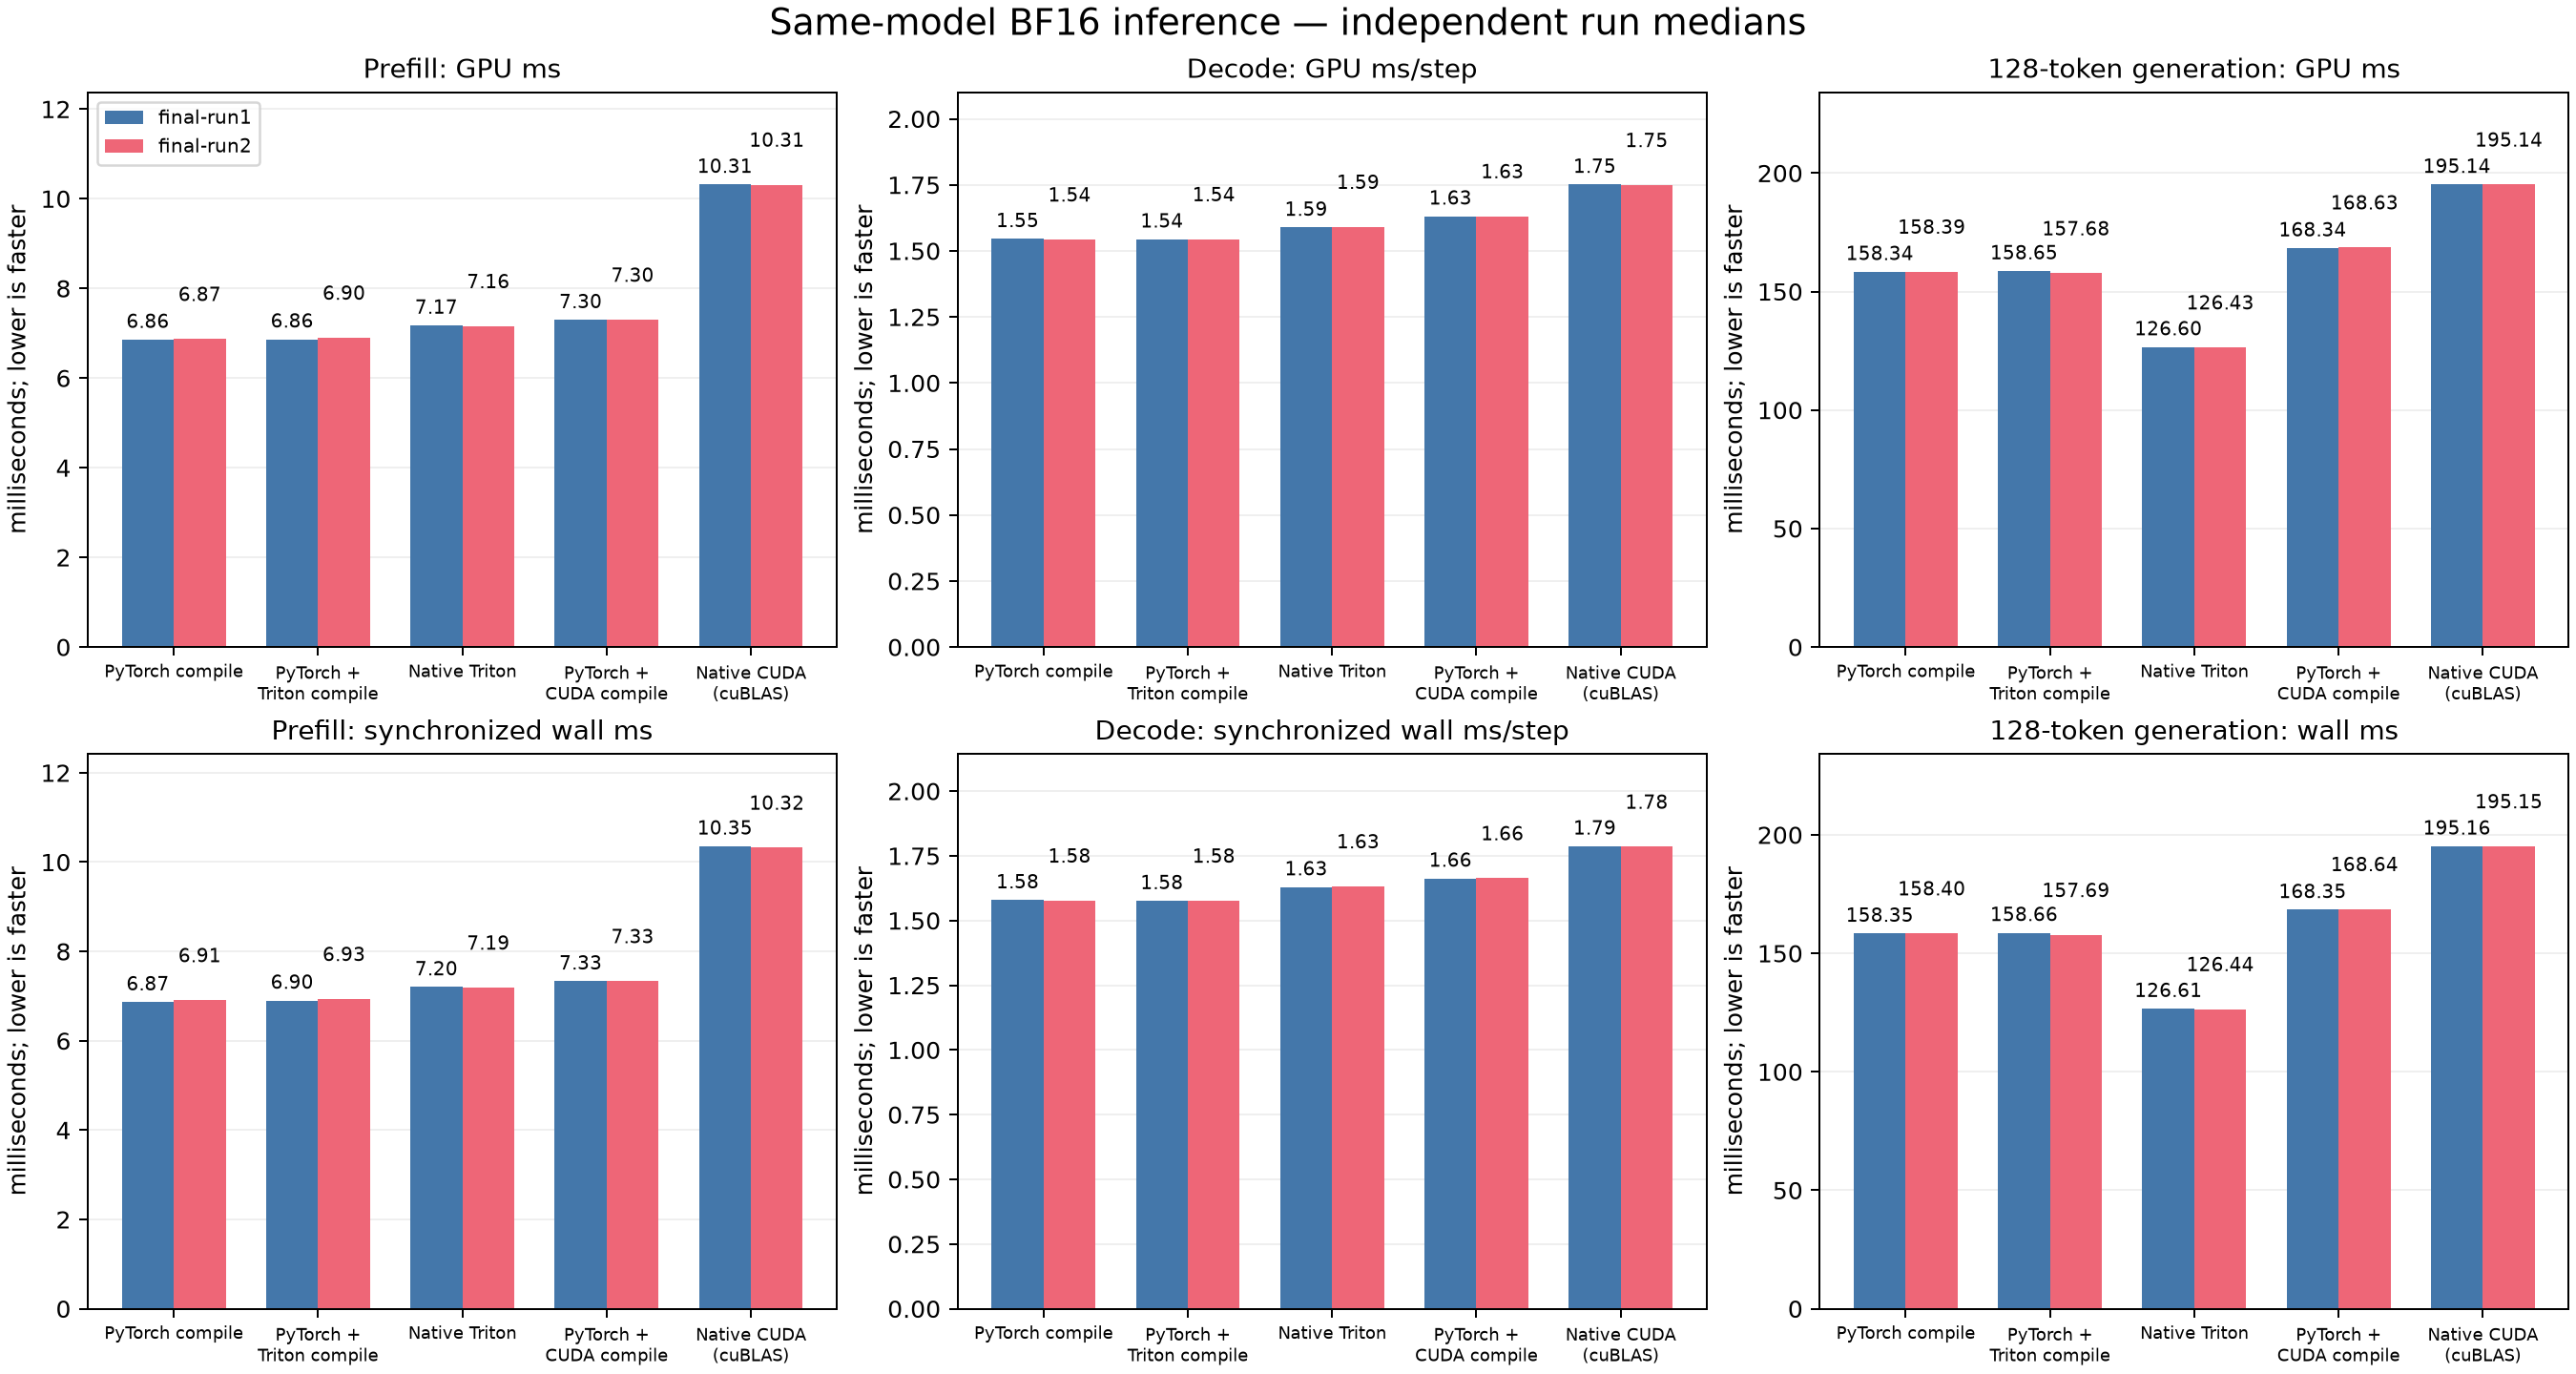

In [4]:
chart_path = RESULTS_DIR / 'charts.png'
plot_records(records, chart_path)
display(Image(filename=str(chart_path)))


In [5]:
# 표본과 실행별 정밀 수치를 보존합니다. 결과를 합쳐 표본 수를 늘리지 않습니다.
import csv
csv_path = RESULTS_DIR / 'summary.csv'
with csv_path.open('w', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(records[0]))
    writer.writeheader()
    writer.writerows(records)
print('CSV:', csv_path)
print('결과 JSON:', RESULTS_DIR)
print('수치 행:', len(records))


CSV: /tmp/llm-cuda-notebook-s6ija3j5/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/summary.csv
결과 JSON: /tmp/llm-cuda-notebook-s6ija3j5/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final
수치 행: 120
